# 01 — Exploratory Data Analysis

Diabetes Risk Prediction — CDC Diabetes Health Indicators (BRFSS 2015)

Structure:
1. Data overview & quality checks
2. Univariate analysis (target, binary features, ordinal/continuous features)
3. Bivariate analysis (every feature vs target)
4. Multivariate analysis (correlation heatmap, pairplot, multicollinearity/VIF)
5. Ranked feature-target associations
6. Summary of findings

Note on method: most features here are binary or ordinal, not continuous, so a
plain Pearson correlation matrix (which strictly assumes continuous/binary
variables) is misleading for categorical-vs-categorical relationships. Section 5
uses the statistically appropriate measure per variable-type pair
(point-biserial, Cramér's V, correlation ratio) via `src/eda.py`.

In [7]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from scipy import stats

from src.data_loader import load_raw_data
from src.utils import load_config, set_seed
from src.eda import (
    point_biserial, cramers_v, correlation_ratio,
    chi_square_test, mann_whitney_test,
    compute_target_associations, compute_vif,
)
from src.plotting import (
    plot_categorical_grid, plot_numeric_distributions,
    plot_bivariate_categorical_grid, plot_bivariate_numeric,
    plot_association_ranking,
)

config = load_config()
set_seed(config["random_seed"])
sns.set_theme(style="whitegrid")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [8]:
df = load_raw_data()
target = config["data"]["target_column"]

# Column groupings by variable type — used throughout this notebook
binary_cols = [
    "HighBP", "HighChol", "CholCheck", "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare",
    "NoDocbcCost", "DiffWalk", "Sex",
]
ordinal_cols = ["GenHlth", "Age", "Education", "Income"]
continuous_cols = ["BMI", "MentHlth", "PhysHlth"]

print(df.shape)
df.head()

2026-09-15 17:43:15 | src.data_loader | INFO | Loading cached raw data from C:\diabetes-risk-prediction\data\raw\diabetes_health_indicators.csv
2026-09-15 17:43:15 | src.data_loader | INFO | Raw data validation passed.


(253680, 22)


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


## 1. Data Overview & Quality Checks

In [9]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum().sum(), "total")
print("\nDuplicate rows:", df.duplicated().sum())
df.describe().T

Shape: (253680, 22)

Dtypes:
 HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object

Missing values:
 0 total

Duplicate rows: 24206


,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


## 2. Univariate Analysis

### 2.1 Target distribution

                  count    pct
Diabetes_binary               
0                218334  86.07
1                 35346  13.93


C:\Users\Huawei\AppData\Local\Temp\ipykernel_17176\1126041882.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["No Diabetes", "Prediabetes/Diabetes"])


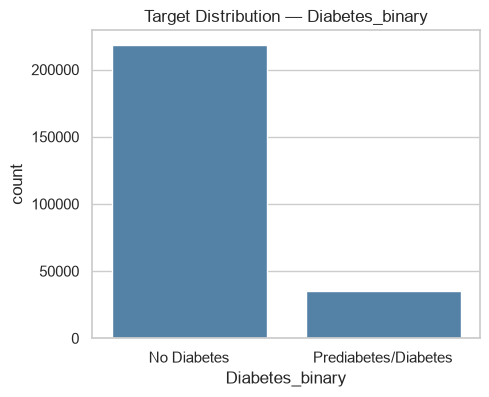


Imbalance ratio: 6.18 : 1


In [10]:
counts = df[target].value_counts()
pct = df[target].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": counts, "pct": pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x=df[target], ax=ax, color="steelblue")
ax.set_title("Target Distribution — Diabetes_binary")
ax.set_xticklabels(["No Diabetes", "Prediabetes/Diabetes"])
plt.savefig(FIG_DIR / "01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nImbalance ratio: {counts[0] / counts[1]:.2f} : 1")

### 2.2 Binary/categorical features — value counts

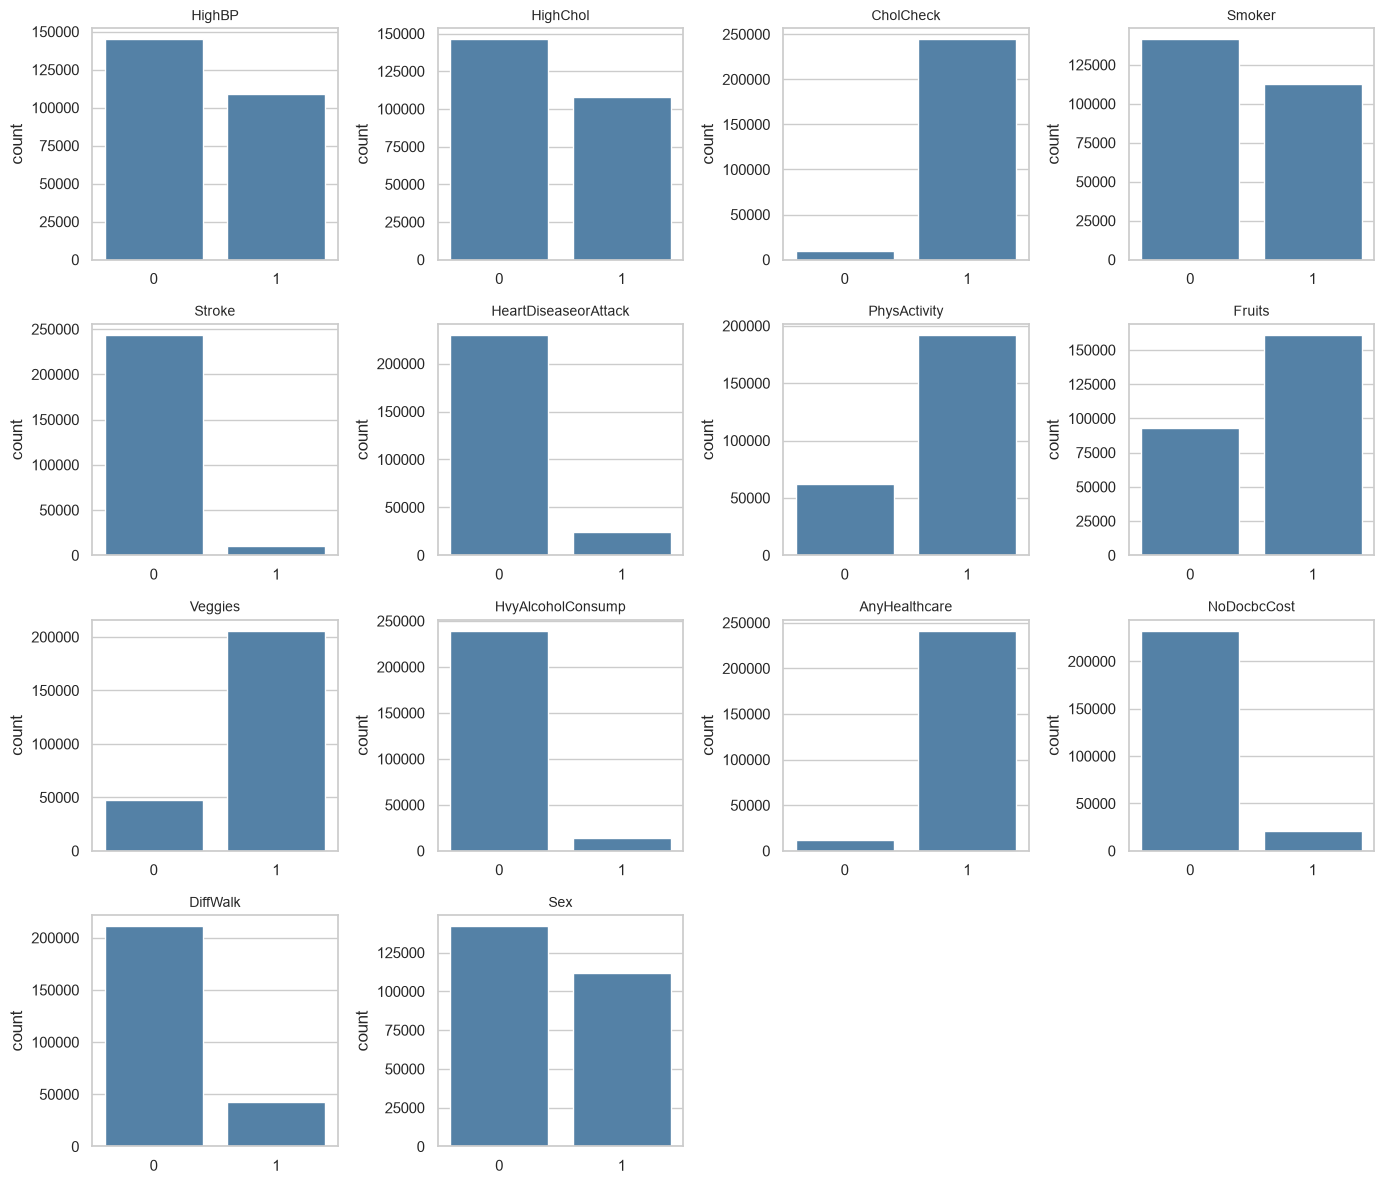

In [11]:
plot_categorical_grid(df, binary_cols, ncols=4, save_path=str(FIG_DIR / "02_univariate_binary.png"))
plt.show()

### 2.3 Ordinal features — value counts

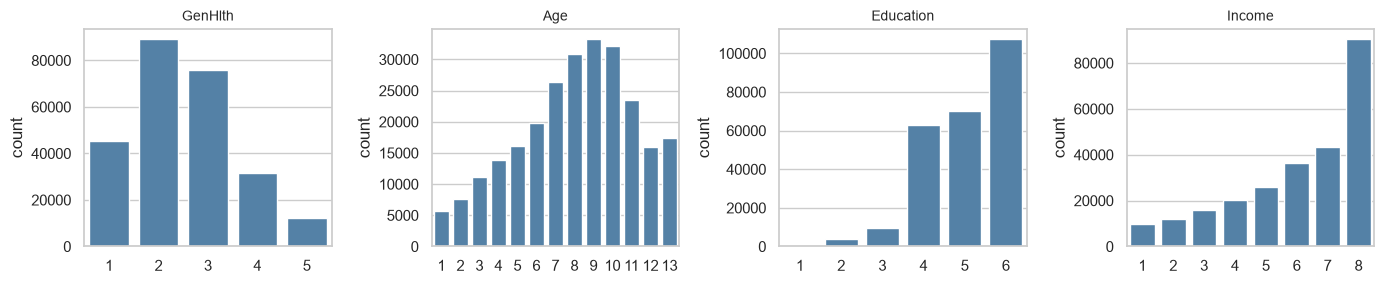

In [12]:
plot_categorical_grid(df, ordinal_cols, ncols=4, save_path=str(FIG_DIR / "03_univariate_ordinal.png"))
plt.show()

### 2.4 Continuous features — distributions

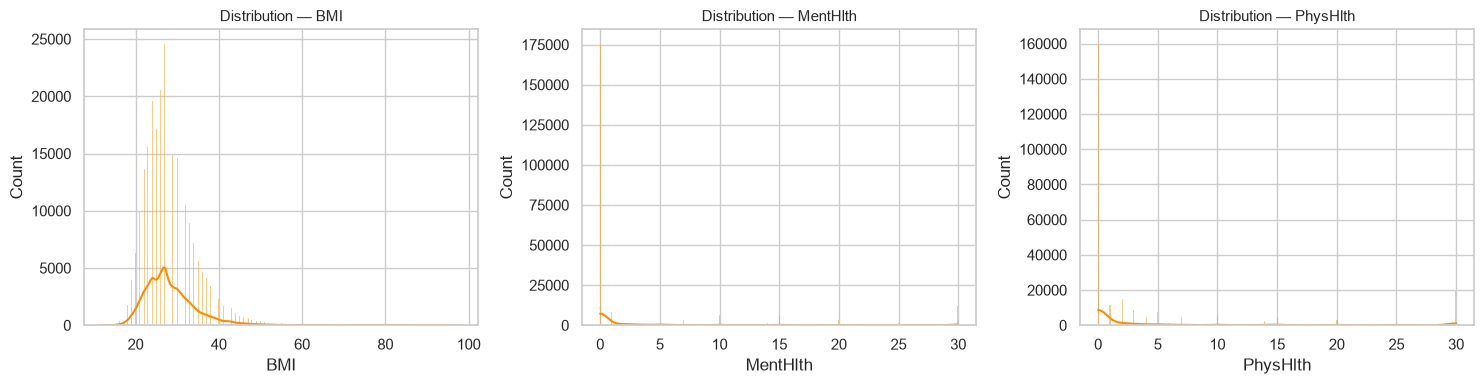

BMI: skewness = 2.12  (highly right-skewed)
MentHlth: skewness = 2.72  (highly right-skewed)
PhysHlth: skewness = 2.21  (highly right-skewed)


In [13]:
plot_numeric_distributions(df, continuous_cols, save_path=str(FIG_DIR / "04_univariate_continuous.png"))
plt.show()

for col in continuous_cols:
    skew = stats.skew(df[col])
    print(f"{col}: skewness = {skew:.2f}" + ("  (highly right-skewed)" if skew > 1 else ""))

## 3. Bivariate Analysis — every feature vs target

### 3.1 Binary features vs target (normalized %, with chi-square test)

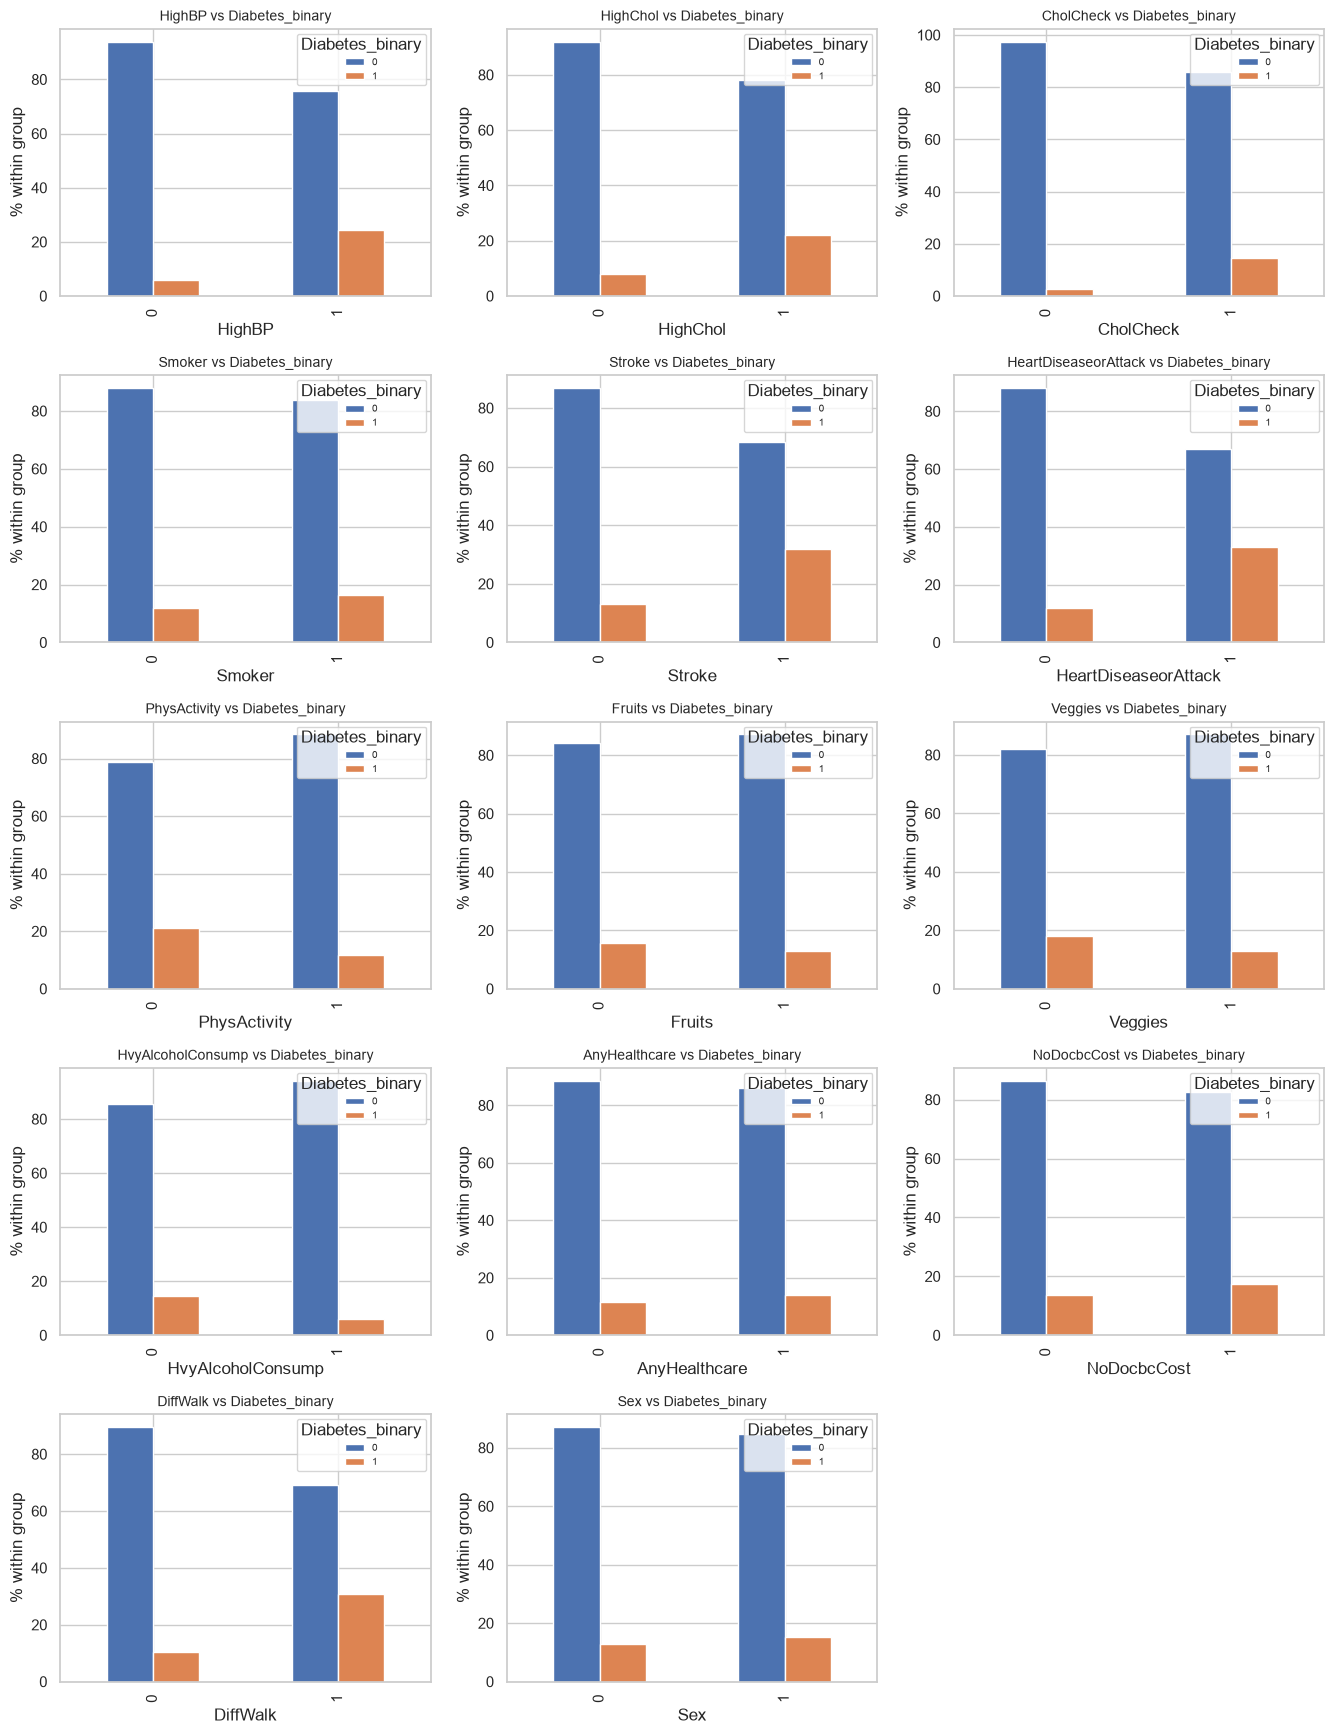

In [14]:
plot_bivariate_categorical_grid(df, binary_cols, target, ncols=3, save_path=str(FIG_DIR / "05_bivariate_binary.png"))
plt.show()

In [15]:
chi2_results = []
for col in binary_cols + ordinal_cols:
    res = chi_square_test(df[col], df[target])
    res["feature"] = col
    chi2_results.append(res)

chi2_df = pd.DataFrame(chi2_results)[["feature", "chi2", "dof", "p_value"]]
chi2_df["significant (p<0.05)"] = chi2_df["p_value"] < 0.05
chi2_df.sort_values("chi2", ascending=False).reset_index(drop=True)

,feature,chi2,dof,p_value,significant (p<0.05)
0,GenHlth,22728.069055,4,0.000000e+00,True
1,HighBP,17562.446090,1,0.000000e+00,True
2,DiffWalk,12092.319741,1,0.000000e+00,True
3,HighChol,10174.074889,1,0.000000e+00,True
4,Age,8795.050614,12,0.000000e+00,True
5,HeartDiseaseorAttack,7971.155841,1,0.000000e+00,True
6,Income,7003.715091,7,0.000000e+00,True
7,Education,4027.112282,5,0.000000e+00,True
8,PhysActivity,3539.419370,1,0.000000e+00,True
9,Stroke,2838.916547,1,0.000000e+00,True


### 3.2 Ordinal features vs target

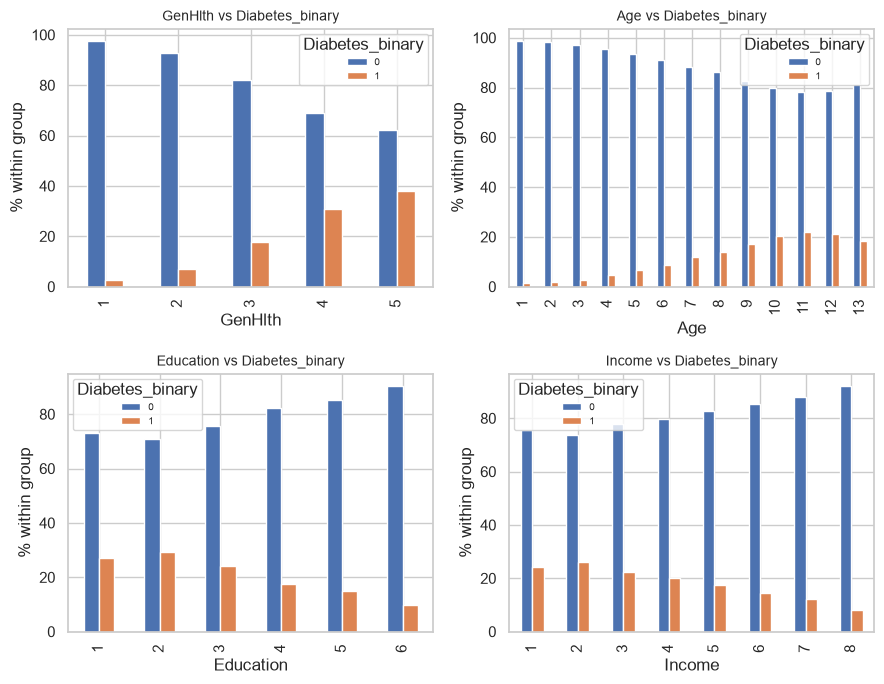

In [16]:
plot_bivariate_categorical_grid(df, ordinal_cols, target, ncols=2, save_path=str(FIG_DIR / "06_bivariate_ordinal.png"))
plt.show()

### 3.3 Continuous features vs target (boxplots + Mann-Whitney U test)

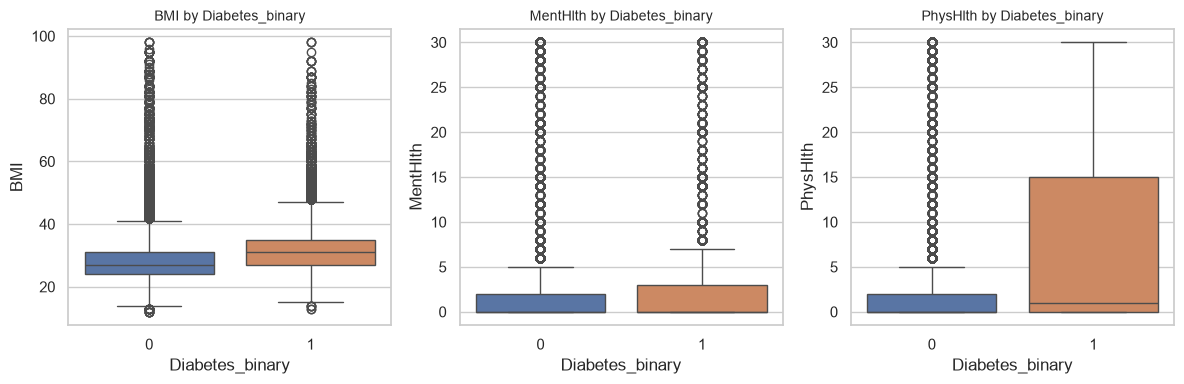

In [17]:
plot_bivariate_numeric(df, continuous_cols, target, ncols=3, save_path=str(FIG_DIR / "07_bivariate_continuous.png"))
plt.show()

In [18]:
mw_results = []
for col in continuous_cols:
    group0 = df.loc[df[target] == 0, col]
    group1 = df.loc[df[target] == 1, col]
    res = mann_whitney_test(group0, group1)
    res["feature"] = col
    res["median_no_diabetes"] = group0.median()
    res["median_diabetes"] = group1.median()
    mw_results.append(res)

pd.DataFrame(mw_results)[["feature", "median_no_diabetes", "median_diabetes", "u_stat", "p_value"]]

,feature,median_no_diabetes,median_diabetes,u_stat,p_value
0,BMI,27.0,31.0,2.405335e+09,0.000000e+00
1,MentHlth,0.0,0.0,3.648124e+09,1.750549e-90
2,PhysHlth,0.0,1.0,2.986457e+09,0.000000e+00


## 4. Multivariate Analysis

### 4.1 Full correlation heatmap (Pearson — informative for binary/continuous pairs, treat with caution for nominal categoricals)

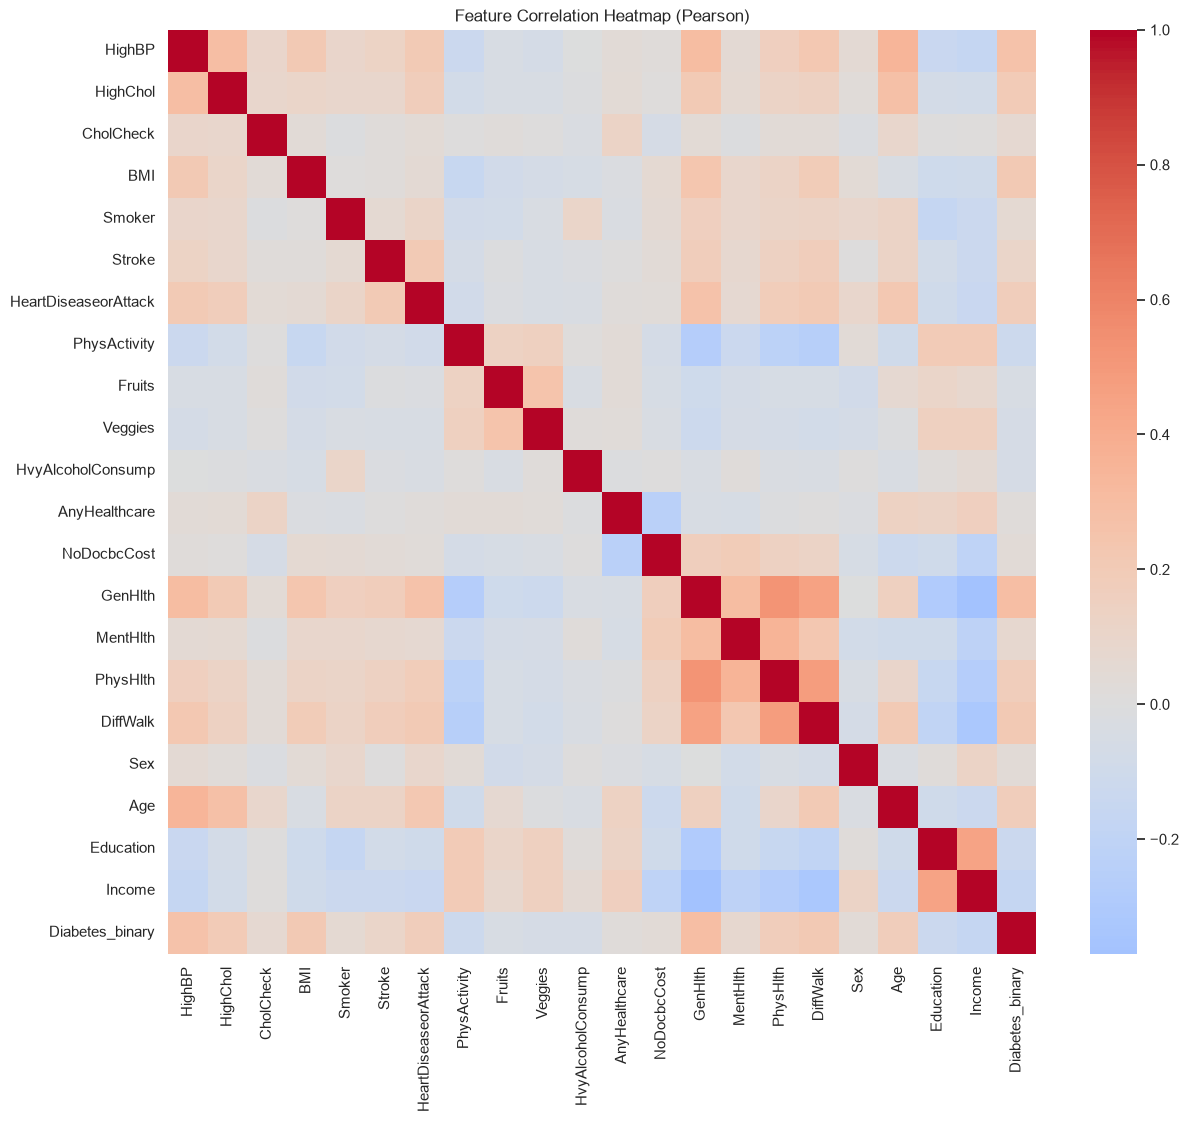

In [19]:
fig, ax = plt.subplots(figsize=(14, 12))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, ax=ax)
ax.set_title("Feature Correlation Heatmap (Pearson)")
plt.savefig(FIG_DIR / "08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Pairwise relationships among top continuous/ordinal features, colored by target

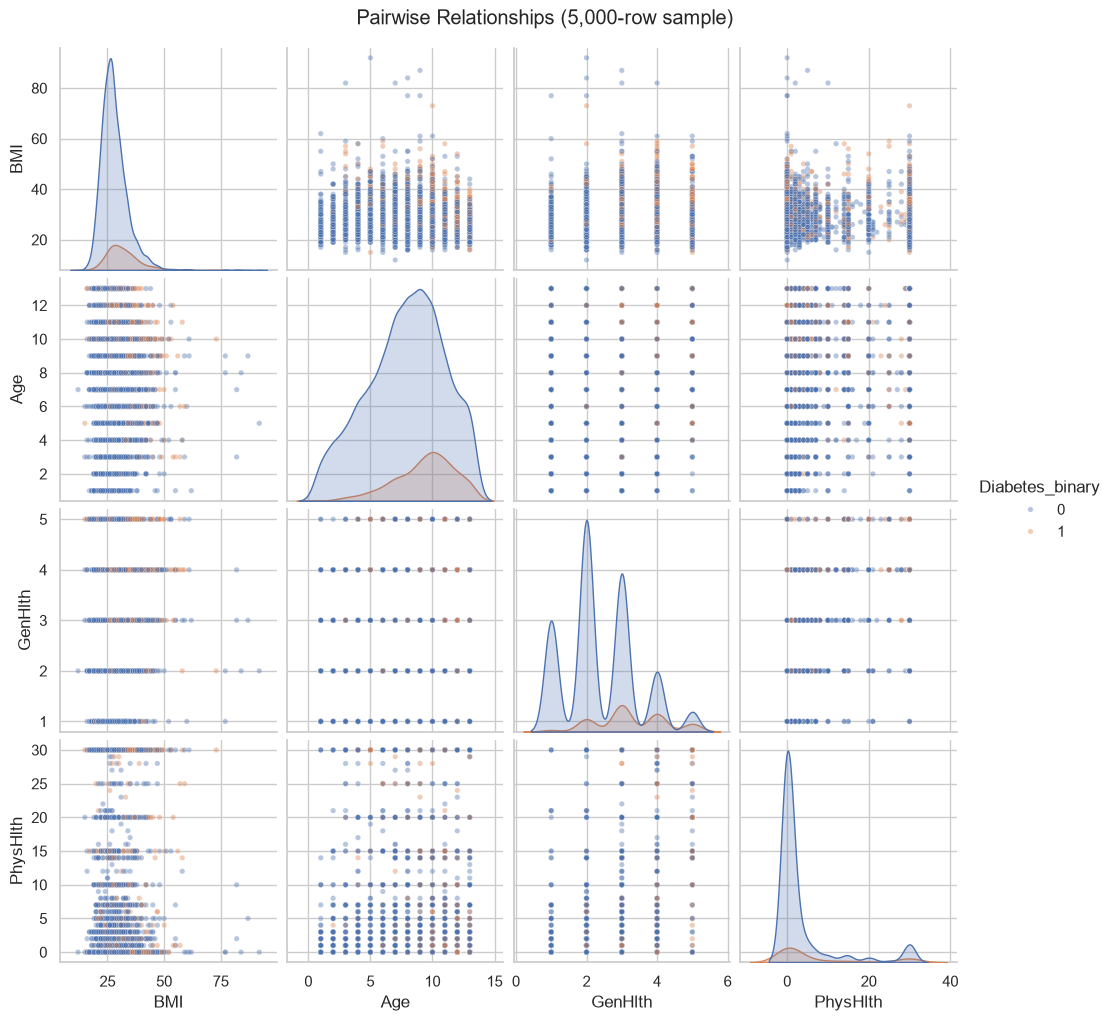

In [20]:
pairplot_cols = ["BMI", "Age", "GenHlth", "PhysHlth", target]
# Sample for speed — pairplot on 253k rows is slow and overplotted anyway
sample = df[pairplot_cols].sample(5000, random_state=config["random_seed"])
g = sns.pairplot(sample, hue=target, palette=["#4c72b0", "#dd8452"], diag_kind="kde", plot_kws={"alpha": 0.4, "s": 15})
g.fig.suptitle("Pairwise Relationships (5,000-row sample)", y=1.02)
g.savefig(FIG_DIR / "09_pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Multicollinearity check (VIF)

In [22]:
vif_cols = [c for c in df.columns if c != target]
vif_df = compute_vif(df, vif_cols)
vif_df

,feature,VIF
0,GenHlth,1.795892
1,PhysHlth,1.623288
2,DiffWalk,1.533902
3,Income,1.503931
4,Age,1.349994
5,HighBP,1.330684
6,Education,1.326390
7,MentHlth,1.239297
8,HighChol,1.173313
9,HeartDiseaseorAttack,1.171917


VIF > 5 warrants a closer look, VIF > 10 signals a real multicollinearity problem
(mainly relevant for logistic regression coefficient interpretation — tree-based
models like Random Forest/XGBoost are largely unaffected by this).

## 5. Ranked Feature-Target Associations

Using the statistically appropriate measure per feature type (see `src/eda.py`) instead
of a blanket Pearson correlation, so ordinal/categorical features aren't misrepresented.

In [23]:
assoc_df = compute_target_associations(
    df, target=target,
    binary_cols=binary_cols, ordinal_cols=ordinal_cols, continuous_cols=continuous_cols,
)
assoc_df

,feature,type,measure,value,abs_value
0,GenHlth,ordinal,point-biserial,0.293569,0.293569
1,HighBP,binary,point-biserial,0.263129,0.263129
2,DiffWalk,binary,point-biserial,0.218344,0.218344
3,BMI,continuous,correlation ratio (eta),0.216843,0.216843
4,HighChol,binary,point-biserial,0.200276,0.200276
5,Age,ordinal,point-biserial,0.177442,0.177442
6,HeartDiseaseorAttack,binary,point-biserial,0.177282,0.177282
7,PhysHlth,continuous,correlation ratio (eta),0.171337,0.171337
8,Income,ordinal,point-biserial,-0.163919,0.163919
9,Education,ordinal,point-biserial,-0.124456,0.124456


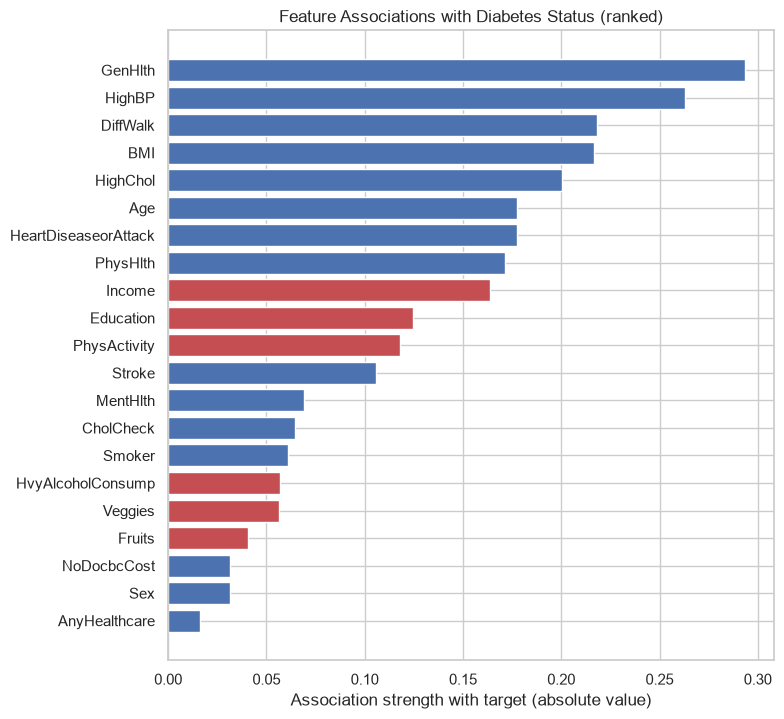

In [24]:
plot_association_ranking(assoc_df, save_path=str(FIG_DIR / "10_association_ranking.png"))
plt.show()

### 5.1 Cramér's V between all nominal/ordinal feature pairs (redundancy check)

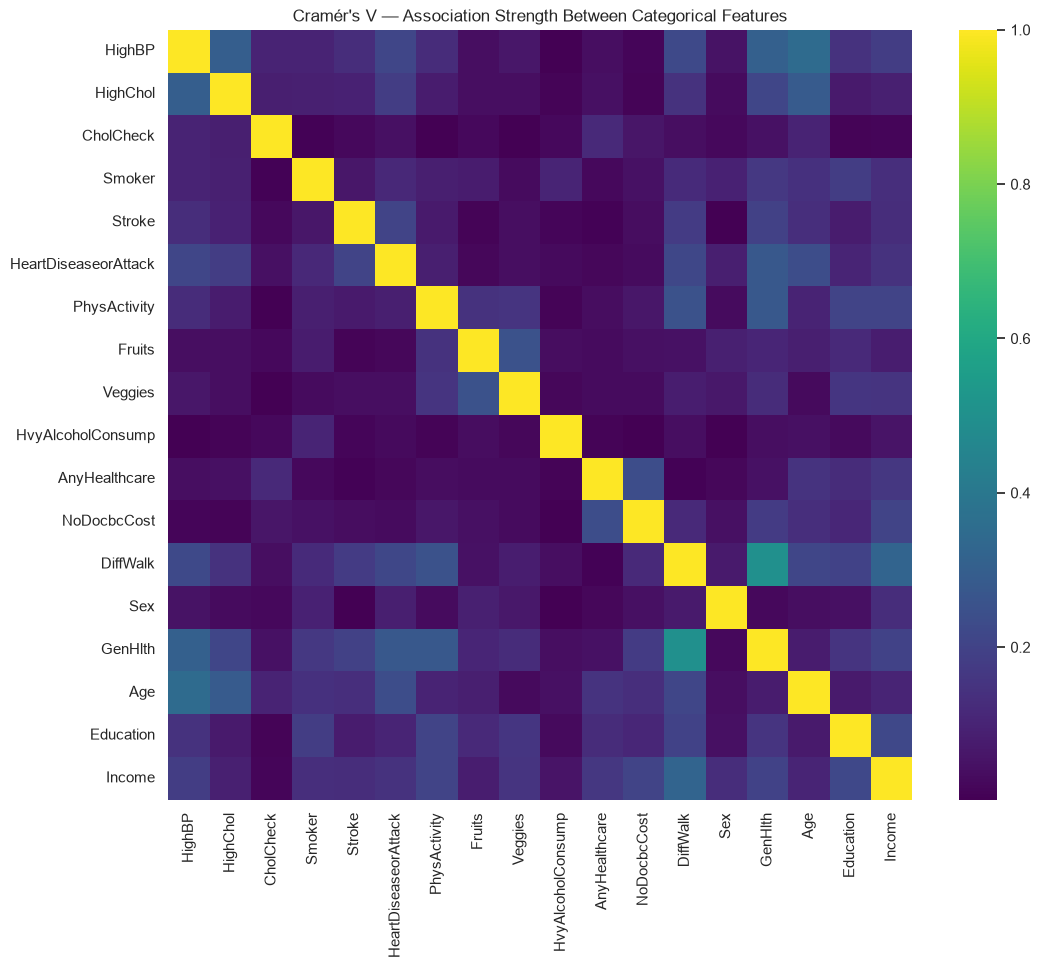

In [25]:
cat_cols = binary_cols + ordinal_cols
cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)

for c1 in cat_cols:
    for c2 in cat_cols:
        cramers_matrix.loc[c1, c2] = cramers_v(df[c1], df[c2]) if c1 != c2 else 1.0

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cramers_matrix.astype(float), cmap="viridis", ax=ax)
ax.set_title("Cramér's V — Association Strength Between Categorical Features")
plt.savefig(FIG_DIR / "11_cramers_v_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Summary of Findings

_Fill in after reviewing the outputs above — capture 3-5 headline observations, e.g.:_
- _Strongest associated features with target (from section 5)_
- _Any pair of near-redundant features (high Cramer's V, section 5.1) to consider dropping/combining_
- _Skewness/outlier notes on MentHlth, PhysHlth, BMI (section 2.4)_
- _Multicollinearity flags from VIF (section 4.3) relevant to logistic regression_
- _Any subgroup pattern worth carrying into feature engineering or risk segmentation_

Next: `02_statistical_analysis.ipynb` for formal hypothesis testing writeup, then `03_feature_engineering.ipynb`.